# Development-only Bayesian fusion: statistical robustness and decision support

Does the current HBAF show a useful Bayesian/adaptive contribution without materially degrading the matched parent and simpler controls?

The unit is one annotated cutting path; experiments are the independent sampling clusters. This notebook loads frozen repeated development predictions only. It performs no model training, architecture selection or evaluation on Internal/External outcomes. Five repeat assignments measure algorithmic stability, not five independent datasets.

Current HBAF and Notebook 03 comparators retain distinct pipeline-cohort labels. This refinement follows previous inspected development results and is exploratory; its confidence intervals do not make it a new sealed confirmation. A negative result is retained.

In [1]:
from __future__ import annotations
from collections.abc import Mapping, Sequence
from pathlib import Path
import hashlib
import json
import math
import time

import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib import font_manager
import numpy as np
import pandas as pd
from IPython.display import Markdown, display
from PIL import Image
from scipy.stats import binomtest
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    average_precision_score, balanced_accuracy_score, f1_score,
    matthews_corrcoef, roc_auc_score,
)

CWD = Path.cwd().resolve()
PROJECT_ROOT = next(path for path in (CWD, *CWD.parents)
    if (path / "notebooks").is_dir() and (path / "dataset").is_dir())
TABLES, FIGURES = PROJECT_ROOT / "artifacts", PROJECT_ROOT / "figures" / "generated"
EVIDENCE = PROJECT_ROOT / "dataset" / "models" / "HBAF_refinement"

FONT_FAMILY = ("Times New Roman" if "Times New Roman" in font_manager.get_font_names()
               else "DejaVu Serif")
for folder in ("figures/generated", "dataset/predictions", "dataset/protocols"):
    (PROJECT_ROOT / folder).mkdir(parents=True, exist_ok=True)


In [2]:
FULL, PARENT = "HBAF", "TabM calibrated"
CURRENT_MODELS = [
    FULL, PARENT, "GaussianNB calibrated", "Global learned fusion",
    "Equal fusion", "MAP gate", "No hierarchy", "Raw TabM",
]
COMPARATORS = [PARENT, "MAP gate", "No hierarchy", "Global learned fusion"]
ENDPOINTS = ["MCC", "PR-AUC", "Macro-F1", "Brier", "NLL"]
NI_MARGINS = {"MCC": 0.010, "PR-AUC": 0.005, "Macro-F1": 0.010}
VALUE_MARGINS = {"Brier": 0.002, "NLL": 0.005}
BOOTSTRAP_REPLICATES, RANDOM_SEED = 5000, 20260917
ALPHA = 0.05
NI_FAMILY_SIZE = len(COMPARATORS) * len(NI_MARGINS)
COVERAGES = np.array([0.50, 0.75, 0.90, 1.00])
SPLIT = "Development OOF"
CURRENT_COHORT = "Current nested-threshold"
BENCHMARK_COHORT = "Notebook03 nested-threshold"
FONT_SIZE, TITLE_SIZE, FIGURE_DPI = 18, 20, 350
SINGLE_COLUMN_MM, DOUBLE_COLUMN_MM = 88.0, 178.0
font_path = Path(font_manager.findfont(FONT_FAMILY, fallback_to_default=False))
mpl.rcParams.update({
    "font.family": FONT_FAMILY, "font.size": FONT_SIZE,
    "axes.titlesize": TITLE_SIZE, "axes.labelsize": FONT_SIZE,
    "xtick.labelsize": FONT_SIZE, "ytick.labelsize": FONT_SIZE,
    "legend.fontsize": FONT_SIZE, "figure.titlesize": TITLE_SIZE,
    "axes.unicode_minus": True, "figure.dpi": FIGURE_DPI,
    "savefig.dpi": FIGURE_DPI, "figure.facecolor": "white",
    "savefig.facecolor": "white",
})


In [30]:
from matplotlib_inline.backend_inline import set_matplotlib_formats
from matplotlib_inline.config import InlineBackend

set_matplotlib_formats("png")
InlineBackend.instance().print_figure_kwargs = {"bbox_inches": None}

def scientific_number(value: float, digits: int = 4) -> str:
    """Format finite values without negative zero or abbreviated output."""
    if not np.isfinite(value):
        return "NA"
    rounded = round(float(value), digits)
    rounded = 0.0 if abs(rounded) < 0.5 * 10 ** (-digits) else rounded
    return f"{rounded:.{digits}f}".replace("-", "−")

def display_grouped_tables(dataframe: pd.DataFrame, identifiers: Sequence[str],
                           groups: Mapping[str, Sequence[str]]) -> None:
    """Display every row and cover each scientific result column once."""
    identifiers = list(identifiers)
    grouped = [name for columns in groups.values() for name in columns]
    assert len(grouped) == len(set(grouped))
    assert set(grouped) == set(dataframe.columns) - set(identifiers)
    assert dataframe[identifiers].notna().all().all()
    for title, columns in groups.items():
        table = dataframe.loc[:, identifiers + list(columns)].copy()
        for name in columns:
            if pd.api.types.is_float_dtype(table[name]):
                is_p = name in {"p raw", "p Holm", "Path-level p; descriptive"}
                table[name] = table[name].map(lambda value: "<0.0001"
                    if is_p and 0 < value < 0.0001 else scientific_number(value))
        with pd.option_context("display.max_rows", None,
                               "display.max_columns", None,
                               "display.max_colwidth", None, "display.width", None):
            display(Markdown(f"#### {title}"))
            display(table.reset_index(drop=True))


In [31]:
def figure_canvas(nrows: int = 1, height_mm: float = 150.0):
    """Create at most two vertically arranged panels at the specified width."""
    assert nrows in (1, 2)
    figure, axes = plt.subplots(
        nrows, 1, figsize=(DOUBLE_COLUMN_MM / 25.4, height_mm / 25.4),
        dpi=FIGURE_DPI, layout="constrained",
    )
    return figure, axes

def save_show(figure, name: str) -> None:
    """Check visible typography and save the complete 350-DPI canvas."""
    from matplotlib.text import Text
    figure.canvas.draw()
    renderer = figure.canvas.get_renderer()
    offscreen = set()
    for axis in figure.axes:
        for scale, limits in [(axis.xaxis, axis.get_xlim()), (axis.yaxis, axis.get_ylim())]:
            offscreen.update(label for value, label in zip(scale.get_ticklocs(), scale.get_ticklabels())
                if value < min(limits) or value > max(limits))
    for artist in figure.findobj(Text):
        if artist in offscreen: continue
        if artist.get_visible() and artist.get_text().strip():
            assert FONT_SIZE <= artist.get_fontsize() <= TITLE_SIZE
            box = artist.get_window_extent(renderer)
            assert figure.bbox.contains(*box.p0) and figure.bbox.contains(*box.p1)
    path = FIGURES / name
    figure.savefig(path, dpi=FIGURE_DPI)
    with Image.open(path) as picture:
        assert abs(picture.info["dpi"][0] - FIGURE_DPI) < 0.1
        assert abs(picture.width / picture.info["dpi"][0] * 25.4
                   - DOUBLE_COLUMN_MM) < 0.2
    plt.show()
    plt.close(figure)


## Matched evidence and experimental support

The comparison uses terminal observations only. All model probabilities must refer to the same paths, outcomes, seeds and experiment-disjoint assessment folds. Each cohort retains its own frozen, training-selected thresholds.

In [5]:
current_path = PROJECT_ROOT / "dataset" / "predictions" / "hbaf_current_oof.parquet"
benchmark_path = PROJECT_ROOT / "dataset" / "predictions" / "model03_seed_oof_predictions.parquet"
protocol_path = PROJECT_ROOT / "dataset" / "protocols" / "hbaf.json"
assert current_path.is_file() and benchmark_path.is_file() and protocol_path.is_file()
protocol = json.loads(protocol_path.read_text())
current = pd.read_parquet(current_path)
benchmark = pd.read_parquet(benchmark_path)
required = {
    "model", "repeat", "seed", "outer_fold", "cutting_path_id",
    "experiment_group_id", "checkpoint", "target", "probability",
    "threshold", "uncertainty", "gate_mean", "gate_variance",
}
assert required.issubset(current.columns)
current = current[np.isclose(current["checkpoint"], 1.0)].copy()
benchmark = benchmark[np.isclose(benchmark["checkpoint"], 1.0)].copy()
assert set(current["model"]) == set(CURRENT_MODELS)
assert benchmark["model"].nunique() == 18
benchmark = benchmark.rename(columns={"oof_probability": "probability"})
current["Cohort"] = CURRENT_COHORT
benchmark["Cohort"] = BENCHMARK_COHORT
shared = ["model", "repeat", "seed", "outer_fold", "cutting_path_id",
          "experiment_group_id", "checkpoint", "target", "probability",
          "threshold", "Cohort"]
ledger = pd.concat([current[shared], benchmark[shared]], ignore_index=True)
assert not ledger.duplicated(["model", "Cohort", "repeat", "cutting_path_id"]).any()
assert ledger["target"].isin([0, 1]).all()
assert ledger["probability"].between(0, 1).all()
assert ledger["threshold"].between(0, 1).all()
input_paths = [current_path, benchmark_path, protocol_path]


In [6]:
identity = ["repeat", "seed", "outer_fold", "cutting_path_id",
            "experiment_group_id", "target"]
reference = current[current["model"].eq(FULL)].sort_values(identity)[identity]
assert reference["repeat"].nunique() == reference["seed"].nunique() == 5
for _, frame in ledger.groupby(["model", "Cohort"], sort=False):
    observed = frame.sort_values(identity)[identity].reset_index(drop=True)
    pd.testing.assert_frame_equal(observed, reference.reset_index(drop=True),
                                  check_dtype=False)
support = ledger.groupby(["Cohort"], sort=False).agg(
    Models=("model", "nunique"), Paths=("cutting_path_id", "nunique"),
    Experiments=("experiment_group_id", "nunique"), Seeds=("seed", "nunique"),
    Folds=("outer_fold", "nunique"),
).reset_index()
support["Split"] = SPLIT
display_grouped_tables(support, ["Cohort", "Split"], {
    "Independent support and repeated assessment": [
        "Models", "Paths", "Experiments", "Seeds", "Folds"],
})


#### Independent support and repeated assessment

,Cohort,Split,Models,Paths,Experiments,Seeds,Folds
0,Current nested-threshold,Development OOF,8,563,11,5,3
1,Notebook03 nested-threshold,Development OOF,18,563,11,5,3


Exact assessment support is shared; pipeline cohorts remain visible because calibration and training differ. Five repeated scores quantify stability on the same development sample and do not multiply its effective sample size.

In [7]:
def bernoulli_nll(target: np.ndarray, probability: np.ndarray) -> np.ndarray:
    """Return finite pointwise Bernoulli logarithmic loss."""
    probability = np.clip(probability, 1e-6, 1 - 1e-6)
    return -(target * np.log(probability)
             + (1 - target) * np.log1p(-probability))

def fixed_ece(target: np.ndarray, probability: np.ndarray) -> float:
    """Use ten prespecified equal-width bins in every notebook."""
    membership = np.minimum((probability * 10).astype(int), 9)
    result = 0.0
    for number in range(10):
        mask = membership == number
        if mask.any():
            result += mask.mean() * abs(target[mask].mean() - probability[mask].mean())
    return float(result)

def safe_ratio(numerator: float, denominator: float) -> float:
    """Report undefined operating rates as missing rather than favorable zero."""
    return float(numerator / denominator) if denominator else np.nan

def calibration_diagnostics(target: np.ndarray, probability: np.ndarray):
    """Fit diagnostic slope/intercept; never alter held-out probabilities."""
    clipped = np.clip(probability, 1e-6, 1 - 1e-6)
    predictor = np.log(clipped / (1 - clipped)).reshape(-1, 1)
    if np.unique(target).size < 2 or np.ptp(predictor) < 1e-12:
        return np.nan, np.nan
    fitted = LogisticRegression(C=1e6, solver="lbfgs", max_iter=500)
    fitted.fit(predictor, target)
    return float(fitted.intercept_[0]), float(fitted.coef_[0, 0])


In [8]:
def experiment_metrics(frame: pd.DataFrame) -> list[dict]:
    """Separate undefined single-class MCC from proper experiment scores."""
    rows = []
    for experiment, local in frame.groupby("experiment_group_id", sort=False):
        target = local["target"].to_numpy(int)
        probability = local["probability"].to_numpy(float)
        predicted = probability >= local["threshold"].to_numpy(float)
        valid = np.unique(target).size == 2
        rows.append({
            "Experiment": experiment, "n": len(local),
            "MCC": matthews_corrcoef(target, predicted) if valid else np.nan,
            "Brier": np.mean((target - probability) ** 2),
            "NLL": bernoulli_nll(target, probability).mean(),
            "MCC eligible": valid,
        })
    return rows

def metric_record(frame: pd.DataFrame) -> dict:
    """Calculate all terminal endpoints on one complete OOF repeat."""
    target = frame["target"].to_numpy(int)
    probability = frame["probability"].to_numpy(float)
    predicted = probability >= frame["threshold"].to_numpy(float)
    tn = np.sum((target == 0) & ~predicted)
    fp = np.sum((target == 0) & predicted)
    fn = np.sum((target == 1) & ~predicted)
    tp = np.sum((target == 1) & predicted)
    groups = pd.DataFrame(experiment_metrics(frame))
    intercept, slope = calibration_diagnostics(target, probability)
    return metric_dictionary(target, probability, predicted, tn, fp, fn, tp,
                             groups, intercept, slope)


In [9]:
def metric_dictionary(target, probability, predicted, tn, fp, fn, tp,
                      groups, intercept, slope) -> dict:
    """Keep primary, operational and probability endpoints explicitly named."""
    return {
        "MCC": matthews_corrcoef(target, predicted),
        "PR-AUC": average_precision_score(target, probability),
        "Macro-F1": f1_score(target, predicted, average="macro", labels=[0, 1]),
        "AUROC": roc_auc_score(target, probability),
        "Precision": safe_ratio(tp, tp + fp),
        "Recall": safe_ratio(tp, tp + fn),
        "Specificity": safe_ratio(tn, tn + fp),
        "FPR": safe_ratio(fp, tn + fp), "FNR": safe_ratio(fn, tp + fn),
        "Balanced Accuracy": balanced_accuracy_score(target, predicted),
        "Brier": np.mean((target - probability) ** 2),
        "NLL": bernoulli_nll(target, probability).mean(),
        "ECE": fixed_ece(target, probability),
        "Calibration intercept": intercept, "Calibration slope": slope,
        "Worst-group MCC": groups["MCC"].min(),
        "Worst-group Brier": groups["Brier"].max(),
        "Worst-group NLL": groups["NLL"].max(),
        "Group MCC SD": groups["MCC"].std(ddof=0),
        "Eligible MCC groups": int(groups["MCC eligible"].sum()),
    }


## Complete predictive, probabilistic and experiment-level comparison

Report every trained comparator and every matched HBAF control. Scores are calculated on each complete OOF repeat before averaging; nonlinear metrics are not averaged across assessment folds.

In [10]:
repeat_rows, group_rows = [], []
model_order = CURRENT_MODELS + list(benchmark["model"].drop_duplicates())
for (model, cohort, repeat), frame in ledger.groupby(
        ["model", "Cohort", "repeat"], sort=False):
    repeat_rows.append({
        "Model": model, "Cohort": cohort, "Split": SPLIT,
        "repeat": int(repeat), "n": frame["cutting_path_id"].nunique(),
        **metric_record(frame),
    })
    for row in experiment_metrics(frame):
        group_rows.append({"Model": model, "Cohort": cohort, "Split": SPLIT,
                           "repeat": int(repeat), **row})
repeat_metrics = pd.DataFrame(repeat_rows)
experiment_results = pd.DataFrame(group_rows)
identifiers = ["Model", "Cohort", "Split", "n"]
result_columns = [name for name in repeat_metrics
                  if name not in identifiers + ["repeat"]]
summary = repeat_metrics.groupby(identifiers, sort=False)[result_columns].mean()
summary["Seeds"] = repeat_metrics.groupby(identifiers, sort=False)["repeat"].nunique()
for metric in ["MCC", "PR-AUC", "Brier"]:
    summary[f"{metric} seed SD"] = repeat_metrics.groupby(
        identifiers, sort=False)[metric].std(ddof=1)
summary = summary.reset_index()
summary["Model"] = pd.Categorical(summary["Model"], model_order, ordered=True)
summary = summary.sort_values("Model").reset_index(drop=True)
assert summary["Seeds"].eq(5).all() and len(summary) == 26
predictive = summary[identifiers + ["Seeds", "MCC", "PR-AUC", "Macro-F1", "AUROC"]]
display_grouped_tables(predictive, identifiers + ["Seeds"], {
    "Terminal predictive quality; higher is better": ["MCC", "PR-AUC", "Macro-F1", "AUROC"],
})


#### Terminal predictive quality; higher is better

,Model,Cohort,Split,n,Seeds,MCC,PR-AUC,Macro-F1,AUROC
0,HBAF,Current nested-threshold,Development OOF,563,5,0.6383,0.8552,0.8126,0.9548
1,TabM calibrated,Current nested-threshold,Development OOF,563,5,0.5437,0.8538,0.7643,0.9376
2,GaussianNB calibrated,Current nested-threshold,Development OOF,563,5,0.5444,0.6764,0.7645,0.9232
3,Global learned fusion,Current nested-threshold,Development OOF,563,5,0.5669,0.8399,0.7731,0.9433
4,Equal fusion,Current nested-threshold,Development OOF,563,5,0.6175,0.8609,0.8013,0.9557
5,MAP gate,Current nested-threshold,Development OOF,563,5,0.4931,0.8300,0.7372,0.9417
6,No hierarchy,Current nested-threshold,Development OOF,563,5,0.6716,0.8252,0.8262,0.9452
7,Raw TabM,Current nested-threshold,Development OOF,563,5,0.6091,0.8487,0.7986,0.9331
8,Dummy — Empirical Prior,Notebook03 nested-threshold,Development OOF,563,5,0.0000,0.1978,0.4364,0.4114
9,Elastic-Net Logistic Regression,Notebook03 nested-threshold,Development OOF,563,5,0.5490,0.7311,0.7704,0.8872


The current calibrated parent isolates the proposed Bayesian contribution. Notebook 03 models remain independent strong comparators; their pipeline names and thresholds are not silently replaced by current controls.

In [11]:
operating_columns = ["Precision", "Recall", "Specificity", "FPR", "FNR",
                     "Balanced Accuracy"]
operating = summary[identifiers + ["Seeds"] + operating_columns]
display_grouped_tables(operating, identifiers + ["Seeds"], {
    "Intervention operating quality": operating_columns,
})


#### Intervention operating quality

,Model,Cohort,Split,n,Seeds,Precision,Recall,Specificity,FPR,FNR,Balanced Accuracy
0,HBAF,Current nested-threshold,Development OOF,563,5,0.6648,0.8031,0.8739,0.1261,0.1969,0.8385
1,TabM calibrated,Current nested-threshold,Development OOF,563,5,0.6096,0.7150,0.8546,0.1454,0.2850,0.7848
2,GaussianNB calibrated,Current nested-threshold,Development OOF,563,5,0.6701,0.6283,0.9046,0.0954,0.3717,0.7665
3,Global learned fusion,Current nested-threshold,Development OOF,563,5,0.6161,0.7512,0.8500,0.1500,0.2488,0.8006
4,Equal fusion,Current nested-threshold,Development OOF,563,5,0.6652,0.7701,0.8752,0.1248,0.2299,0.8227
5,MAP gate,Current nested-threshold,Development OOF,563,5,0.5473,0.7181,0.8165,0.1835,0.2819,0.7673
6,No hierarchy,Current nested-threshold,Development OOF,563,5,0.6652,0.8614,0.8661,0.1339,0.1386,0.8637
7,Raw TabM,Current nested-threshold,Development OOF,563,5,0.6389,0.7827,0.8674,0.1326,0.2173,0.8251
8,Dummy — Empirical Prior,Notebook03 nested-threshold,Development OOF,563,5,NA,0.0000,1.0000,0.0000,1.0000,0.5000
9,Elastic-Net Logistic Regression,Notebook03 nested-threshold,Development OOF,563,5,0.6074,0.7181,0.8615,0.1385,0.2819,0.7898


Precision and recall express different operational costs. Undefined precision for a model predicting no interventions is shown as NA and cannot become a favorable optimum.

In [12]:
probability_columns = ["Brier", "NLL", "ECE", "Calibration intercept",
                       "Calibration slope"]
probability_summary = summary[identifiers + ["Seeds"] + probability_columns]
display_grouped_tables(probability_summary, identifiers + ["Seeds"], {
    "Probability scores; lower is better": ["Brier", "NLL", "ECE"],
    "Diagnostic calibration; intercept→0, slope→1": [
        "Calibration intercept", "Calibration slope"],
})


#### Probability scores; lower is better

,Model,Cohort,Split,n,Seeds,Brier,NLL,ECE
0,HBAF,Current nested-threshold,Development OOF,563,5,0.0773,0.2420,0.0585
1,TabM calibrated,Current nested-threshold,Development OOF,563,5,0.0877,0.3389,0.0736
2,GaussianNB calibrated,Current nested-threshold,Development OOF,563,5,0.0944,0.2947,0.0818
3,Global learned fusion,Current nested-threshold,Development OOF,563,5,0.0788,0.2531,0.0551
4,Equal fusion,Current nested-threshold,Development OOF,563,5,0.0737,0.2313,0.0500
5,MAP gate,Current nested-threshold,Development OOF,563,5,0.0890,0.2970,0.0683
6,No hierarchy,Current nested-threshold,Development OOF,563,5,0.0865,0.2776,0.0755
7,Raw TabM,Current nested-threshold,Development OOF,563,5,0.1113,0.3639,0.1182
8,Dummy — Empirical Prior,Notebook03 nested-threshold,Development OOF,563,5,0.1783,0.5439,0.0047
9,Elastic-Net Logistic Regression,Notebook03 nested-threshold,Development OOF,563,5,0.1063,0.3428,0.0675


#### Diagnostic calibration; intercept→0, slope→1

,Model,Cohort,Split,n,Seeds,Calibration intercept,Calibration slope
0,HBAF,Current nested-threshold,Development OOF,563,5,−0.4106,1.0137
1,TabM calibrated,Current nested-threshold,Development OOF,563,5,−0.4394,0.5241
2,GaussianNB calibrated,Current nested-threshold,Development OOF,563,5,−0.4020,0.8418
3,Global learned fusion,Current nested-threshold,Development OOF,563,5,−0.2464,0.9807
4,Equal fusion,Current nested-threshold,Development OOF,563,5,−0.2961,1.1375
5,MAP gate,Current nested-threshold,Development OOF,563,5,−0.5272,0.7633
6,No hierarchy,Current nested-threshold,Development OOF,563,5,−0.4933,0.8468
7,Raw TabM,Current nested-threshold,Development OOF,563,5,−1.3513,0.6652
8,Dummy — Empirical Prior,Notebook03 nested-threshold,Development OOF,563,5,−4.5020,−2.6667
9,Elastic-Net Logistic Regression,Notebook03 nested-threshold,Development OOF,563,5,0.0462,0.7803


Calibration regression is diagnostic and does not recalibrate predictions. Ten fixed-width ECE bins are used consistently; Brier and NLL remain the proper probability-score endpoints.

In [13]:
robustness_columns = [
    "Worst-group MCC", "Worst-group Brier", "Worst-group NLL",
    "Group MCC SD", "Eligible MCC groups",
    "MCC seed SD", "PR-AUC seed SD", "Brier seed SD",
]
robustness = summary[identifiers + ["Seeds"] + robustness_columns]
display_grouped_tables(robustness, identifiers + ["Seeds"], {
    "Worst experiment; MCC↑, Brier/NLL↓": [
        "Worst-group MCC", "Worst-group Brier", "Worst-group NLL"],
    "Heterogeneity and MCC support": ["Group MCC SD", "Eligible MCC groups"],
    "Repeated-assignment stability; lower is better": [
        "MCC seed SD", "PR-AUC seed SD", "Brier seed SD"],
})


#### Worst experiment; MCC↑, Brier/NLL↓

,Model,Cohort,Split,n,Seeds,Worst-group MCC,Worst-group Brier,Worst-group NLL
0,HBAF,Current nested-threshold,Development OOF,563,5,−0.0512,0.5351,1.4523
1,TabM calibrated,Current nested-threshold,Development OOF,563,5,0.0000,0.6202,2.4244
2,GaussianNB calibrated,Current nested-threshold,Development OOF,563,5,−0.0596,0.6805,1.8998
3,Global learned fusion,Current nested-threshold,Development OOF,563,5,0.0000,0.5923,1.7603
4,Equal fusion,Current nested-threshold,Development OOF,563,5,−0.0512,0.5912,1.6414
5,MAP gate,Current nested-threshold,Development OOF,563,5,0.0180,0.5691,1.7042
6,No hierarchy,Current nested-threshold,Development OOF,563,5,−0.0145,0.5541,1.6135
7,Raw TabM,Current nested-threshold,Development OOF,563,5,0.0526,0.5540,1.6010
8,Dummy — Empirical Prior,Notebook03 nested-threshold,Development OOF,563,5,0.0000,0.5395,1.3706
9,Elastic-Net Logistic Regression,Notebook03 nested-threshold,Development OOF,563,5,0.2565,0.4789,1.4358


#### Heterogeneity and MCC support

,Model,Cohort,Split,n,Seeds,Group MCC SD,Eligible MCC groups
0,HBAF,Current nested-threshold,Development OOF,563,5,0.3143,3.0000
1,TabM calibrated,Current nested-threshold,Development OOF,563,5,0.3440,3.0000
2,GaussianNB calibrated,Current nested-threshold,Development OOF,563,5,0.1170,3.0000
3,Global learned fusion,Current nested-threshold,Development OOF,563,5,0.1504,3.0000
4,Equal fusion,Current nested-threshold,Development OOF,563,5,0.2813,3.0000
5,MAP gate,Current nested-threshold,Development OOF,563,5,0.2193,3.0000
6,No hierarchy,Current nested-threshold,Development OOF,563,5,0.2860,3.0000
7,Raw TabM,Current nested-threshold,Development OOF,563,5,0.4124,3.0000
8,Dummy — Empirical Prior,Notebook03 nested-threshold,Development OOF,563,5,0.0000,3.0000
9,Elastic-Net Logistic Regression,Notebook03 nested-threshold,Development OOF,563,5,0.3083,3.0000


#### Repeated-assignment stability; lower is better

,Model,Cohort,Split,n,Seeds,MCC seed SD,PR-AUC seed SD,Brier seed SD
0,HBAF,Current nested-threshold,Development OOF,563,5,0.1035,0.0504,0.0176
1,TabM calibrated,Current nested-threshold,Development OOF,563,5,0.0419,0.0557,0.0192
2,GaussianNB calibrated,Current nested-threshold,Development OOF,563,5,0.1542,0.0901,0.0255
3,Global learned fusion,Current nested-threshold,Development OOF,563,5,0.0487,0.0366,0.0130
4,Equal fusion,Current nested-threshold,Development OOF,563,5,0.0794,0.0544,0.0186
5,MAP gate,Current nested-threshold,Development OOF,563,5,0.1041,0.0482,0.0146
6,No hierarchy,Current nested-threshold,Development OOF,563,5,0.0740,0.0779,0.0244
7,Raw TabM,Current nested-threshold,Development OOF,563,5,0.0932,0.0618,0.0206
8,Dummy — Empirical Prior,Notebook03 nested-threshold,Development OOF,563,5,0.0000,0.0000,0.0000
9,Elastic-Net Logistic Regression,Notebook03 nested-threshold,Development OOF,563,5,0.1006,0.1102,0.0238


Experiment MCC includes every mixed-target experiment, regardless of prediction degeneracy. Constant predictions on mixed-target experiments receive the standard MCC of zero, preserving those failures in worst-group comparisons. Single-class target experiments remain NA for MCC. Eligibility therefore depends only on observed targets and is identical across models; Brier/NLL cover every experiment.

## Prespecified paired hypotheses

The four matched comparisons are HBAF versus calibrated parent, MAP gate, no hierarchy and global learned fusion. Predictive non-inferiority margins are fixed at 0.010 MCC, 0.005 PR-AUC and 0.010 Macro-F1. Practical probability gains are 0.002 Brier or 0.005 NLL.

Hierarchical bootstrap uncertainty uses 5,000 paired samples. One-sided non-inferiority bounds are multiplicity-controlled across 12 predictive comparisons. Exact experiment-block swaps test positive superiority relative to zero, with Holm correction across the 20 endpoint/comparator tests. Equality permutation p-values are not mislabelled as tests at a nonzero non-inferiority margin.

In [14]:
def paired_cache(frame: pd.DataFrame, model: str) -> dict:
    """Align each model to identical paths in each frozen OOF repeat."""
    repeats = sorted(frame["repeat"].unique())
    source = frame[frame["model"].eq(model)]
    parts = [source[source["repeat"].eq(repeat)].sort_values("cutting_path_id")
             for repeat in repeats]
    paths = parts[0]["cutting_path_id"].to_numpy(str)
    target = parts[0]["target"].to_numpy(int)
    groups = parts[0]["experiment_group_id"].to_numpy(str)
    for part in parts:
        assert np.array_equal(paths, part["cutting_path_id"].to_numpy(str))
        assert np.array_equal(target, part["target"].to_numpy(int))
        assert np.array_equal(groups, part["experiment_group_id"].to_numpy(str))
    return {
        "path": paths, "target": target, "group": groups,
        "p": np.stack([part["probability"].to_numpy(float) for part in parts]),
        "t": np.stack([part["threshold"].to_numpy(float) for part in parts]),
        "u": np.stack([part["uncertainty"].to_numpy(float) for part in parts]),
    }

caches = {model: paired_cache(current, model) for model in CURRENT_MODELS}
reference_cache = caches[FULL]
target_array = reference_cache["target"]
group_array = reference_cache["group"]
group_labels = np.unique(group_array)
group_positions = [np.flatnonzero(group_array == group) for group in group_labels]
PERMUTATIONS = 2 ** len(group_labels)
assert len(group_labels) == 11 and PERMUTATIONS == 2048
for cache in caches.values():
    assert np.array_equal(cache["path"], reference_cache["path"])
    assert np.isfinite(cache["p"]).all()


In [15]:
def repeated_ap(target: np.ndarray, probabilities: np.ndarray) -> np.ndarray:
    """Compute average precision with exact handling of probability ties."""
    result = []
    positives = target.sum()
    for probability in probabilities:
        order = np.argsort(-probability, kind="stable")
        cumulative = np.cumsum(target[order])
        ends = np.r_[np.flatnonzero(np.diff(probability[order])), len(order) - 1]
        increments = np.diff(np.r_[0, cumulative[ends]])
        precision = cumulative[ends] / (ends + 1)
        result.append(float(np.sum(increments * precision) / positives))
    return np.asarray(result)

def metric_vector(target: np.ndarray, probabilities: np.ndarray,
                  thresholds: np.ndarray) -> np.ndarray:
    """Return five endpoints for every fixed repeat, without refitting."""
    truth = target[None, :]
    predicted = probabilities >= thresholds
    tp = ((truth == 1) & predicted).sum(axis=1)
    tn = ((truth == 0) & ~predicted).sum(axis=1)
    fp = ((truth == 0) & predicted).sum(axis=1)
    fn = ((truth == 1) & ~predicted).sum(axis=1)
    denominator = np.sqrt((tp + fp) * (tp + fn) * (tn + fp) * (tn + fn))
    mcc = np.divide(tp * tn - fp * fn, denominator,
                    out=np.zeros(len(tp), dtype=float), where=denominator > 0)
    positive_f1 = np.divide(2 * tp, 2 * tp + fp + fn)
    negative_f1 = np.divide(2 * tn, 2 * tn + fp + fn)
    return np.column_stack([
        mcc, repeated_ap(target, probabilities), (positive_f1 + negative_f1) / 2,
        np.mean((probabilities - truth) ** 2, axis=1),
        bernoulli_nll(truth, probabilities).mean(axis=1),
    ])


In [16]:
ORIENTATIONS = np.array([1, 1, 1, -1, -1], dtype=float)

def paired_effect(target, full_probability, full_threshold,
                  other_probability, other_threshold) -> np.ndarray:
    """Orient every endpoint so a positive effect favors HBAF."""
    full = metric_vector(target, full_probability, full_threshold)
    other = metric_vector(target, other_probability, other_threshold)
    return (full - other) * ORIENTATIONS

point_effects = {}
for comparator in COMPARATORS:
    other = caches[comparator]
    point_effects[comparator] = paired_effect(
        target_array, reference_cache["p"], reference_cache["t"],
        other["p"], other["t"],
    )
full_check = metric_vector(target_array, reference_cache["p"], reference_cache["t"])
observed_check = repeat_metrics[repeat_metrics["Model"].eq(FULL)].sort_values("repeat")
assert np.allclose(full_check, observed_check[ENDPOINTS].to_numpy(), atol=1e-12)


In [17]:
def hierarchical_sample(generator: np.random.Generator) -> np.ndarray:
    """Resample experiment clusters, then paths within each sampled cluster."""
    selected = generator.integers(0, len(group_positions), len(group_positions))
    return np.concatenate([
        generator.choice(group_positions[index], len(group_positions[index]), replace=True)
        for index in selected
    ])

def paired_bootstrap() -> np.ndarray:
    """Use one sample for every model and every repeat in each bootstrap draw."""
    generator = np.random.default_rng(RANDOM_SEED)
    draws = np.empty((BOOTSTRAP_REPLICATES, len(COMPARATORS), len(ENDPOINTS)))
    accepted = 0
    while accepted < BOOTSTRAP_REPLICATES:
        indices = hierarchical_sample(generator)
        target = target_array[indices]
        if np.unique(target).size < 2:
            continue
        full = metric_vector(target, reference_cache["p"][:, indices],
                             reference_cache["t"][:, indices])
        for number, comparator in enumerate(COMPARATORS):
            other = caches[comparator]
            score = metric_vector(target, other["p"][:, indices], other["t"][:, indices])
            draws[accepted, number] = ((full - score) * ORIENTATIONS).mean(axis=0)
        accepted += 1
    return draws


## Hierarchical uncertainty of matched effects

The same experiment/path sample is used for HBAF, each comparator and all five repeats. This preserves pairing and avoids counting the same path five times as independent information. Draws containing only one target class are rejected; these AP/MCC intervals are conditional on resampled outcomes retaining both classes.

In [18]:
bootstrap_draws = paired_bootstrap()
bootstrap_rows = []
for number, comparator in enumerate(COMPARATORS):
    for column, metric in enumerate(ENDPOINTS):
        values = bootstrap_draws[:, number, column]
        bootstrap_rows.append({
            "Comparator": comparator, "Metric": metric,
            "Effect": point_effects[comparator][:, column].mean(),
            "CI low": np.quantile(values, 0.025),
            "CI high": np.quantile(values, 0.975),
            "Replicates": BOOTSTRAP_REPLICATES,
        })
bootstrap_summary = pd.DataFrame(bootstrap_rows)
display_grouped_tables(bootstrap_summary, ["Comparator", "Metric", "Replicates"], {
    "Paired favorable effect and hierarchical 95% interval": ["Effect", "CI low", "CI high"],
})


#### Paired favorable effect and hierarchical 95% interval

,Comparator,Metric,Replicates,Effect,CI low,CI high
0,TabM calibrated,MCC,5000,0.0946,−0.0016,0.2531
1,TabM calibrated,PR-AUC,5000,0.0014,−0.0835,0.0958
2,TabM calibrated,Macro-F1,5000,0.0483,−0.0046,0.1280
3,TabM calibrated,Brier,5000,0.0105,−0.0088,0.0360
4,TabM calibrated,NLL,5000,0.0969,−0.0065,0.2570
5,MAP gate,MCC,5000,0.1452,0.0126,0.2460
6,MAP gate,PR-AUC,5000,0.0252,0.0022,0.0920
7,MAP gate,Macro-F1,5000,0.0753,0.0131,0.1325
8,MAP gate,Brier,5000,0.0117,0.0002,0.0262
9,MAP gate,NLL,5000,0.0550,0.0047,0.1107


A positive effect favors HBAF. Intervals crossing zero do not establish superiority. The intervals describe development-sample and experiment heterogeneity; they do not constitute independent external confirmation.

In [19]:
def exact_block_permutation(comparator: str) -> np.ndarray:
    """Enumerate all experiment-level label swaps, shared across repeats."""
    other = caches[comparator]
    null = np.empty((PERMUTATIONS, len(ENDPOINTS)))
    for assignment in range(PERMUTATIONS):
        swap = np.zeros(len(target_array), dtype=bool)
        for number, positions in enumerate(group_positions):
            if assignment & (1 << number):
                swap[positions] = True
        full_p = np.where(swap[None, :], other["p"], reference_cache["p"])
        other_p = np.where(swap[None, :], reference_cache["p"], other["p"])
        full_t = np.where(swap[None, :], other["t"], reference_cache["t"])
        other_t = np.where(swap[None, :], reference_cache["t"], other["t"])
        null[assignment] = paired_effect(
            target_array, full_p, full_t, other_p, other_t,
        ).mean(axis=0)
    observed = point_effects[comparator].mean(axis=0)
    assert np.allclose(null[0], observed)
    return np.mean(null >= observed[None, :] - 1e-12, axis=0)

def holm_adjust(values: np.ndarray) -> np.ndarray:
    """Control the complete prespecified family with monotone Holm p-values."""
    order = np.argsort(values)
    result, previous = np.empty(len(values)), 0.0
    for position, index in enumerate(order):
        previous = max(previous, (len(values) - position) * values[index])
        result[index] = min(previous, 1.0)
    return result


## Exact experiment-block tests and non-inferiority

The permutation test exchanges complete experiment predictions and their frozen thresholds. Holm-adjusted p-values address positive superiority over zero; non-inferiority uses separately labelled multiplicity-controlled bootstrap bounds.

In [20]:
permutation_p = {comparator: exact_block_permutation(comparator)
                 for comparator in COMPARATORS}
statistical_rows = []
for number, comparator in enumerate(COMPARATORS):
    for column, metric in enumerate(ENDPOINTS):
        values = bootstrap_draws[:, number, column]
        effect = point_effects[comparator][:, column].mean()
        margin = NI_MARGINS.get(metric, VALUE_MARGINS.get(metric))
        ni_lower = np.quantile(values, ALPHA / NI_FAMILY_SIZE)
        statistical_rows.append({
            "Comparator": comparator, "Metric": metric,
            "Hypothesis": "Predictive NI" if metric in NI_MARGINS else "Probability superiority",
            "Effect": effect, "CI low": np.quantile(values, 0.025),
            "CI high": np.quantile(values, 0.975), "NI lower bound": ni_lower,
            "p raw": permutation_p[comparator][column],
            "Favorable seeds": int((point_effects[comparator][:, column] > 0).sum()),
            "Replicates": BOOTSTRAP_REPLICATES, "Margin": margin,
        })
statistics = pd.DataFrame(statistical_rows)
statistics["p Holm"] = holm_adjust(statistics["p raw"].to_numpy())
display_grouped_tables(statistics, ["Comparator", "Metric", "Hypothesis", "Replicates"], {
    "Effect and 95% uncertainty": ["Effect", "CI low", "CI high"],
    "Controlled NI bound and practical margin": ["NI lower bound", "Margin"],
    "Experiment-level hypothesis tests": [
        "p raw", "p Holm", "Favorable seeds"],
})


#### Effect and 95% uncertainty

,Comparator,Metric,Hypothesis,Replicates,Effect,CI low,CI high
0,TabM calibrated,MCC,Predictive NI,5000,0.0946,−0.0016,0.2531
1,TabM calibrated,PR-AUC,Predictive NI,5000,0.0014,−0.0835,0.0958
2,TabM calibrated,Macro-F1,Predictive NI,5000,0.0483,−0.0046,0.1280
3,TabM calibrated,Brier,Probability superiority,5000,0.0105,−0.0088,0.0360
4,TabM calibrated,NLL,Probability superiority,5000,0.0969,−0.0065,0.2570
5,MAP gate,MCC,Predictive NI,5000,0.1452,0.0126,0.2460
6,MAP gate,PR-AUC,Predictive NI,5000,0.0252,0.0022,0.0920
7,MAP gate,Macro-F1,Predictive NI,5000,0.0753,0.0131,0.1325
8,MAP gate,Brier,Probability superiority,5000,0.0117,0.0002,0.0262
9,MAP gate,NLL,Probability superiority,5000,0.0550,0.0047,0.1107


#### Controlled NI bound and practical margin

,Comparator,Metric,Hypothesis,Replicates,NI lower bound,Margin
0,TabM calibrated,MCC,Predictive NI,5000,−0.0276,0.0100
1,TabM calibrated,PR-AUC,Predictive NI,5000,−0.1739,0.0050
2,TabM calibrated,Macro-F1,Predictive NI,5000,−0.0147,0.0100
3,TabM calibrated,Brier,Probability superiority,5000,−0.0155,0.0020
4,TabM calibrated,NLL,Probability superiority,5000,−0.0259,0.0050
5,MAP gate,MCC,Predictive NI,5000,−0.0412,0.0100
6,MAP gate,PR-AUC,Predictive NI,5000,−0.0013,0.0050
7,MAP gate,Macro-F1,Predictive NI,5000,−0.0183,0.0100
8,MAP gate,Brier,Probability superiority,5000,−0.0006,0.0020
9,MAP gate,NLL,Probability superiority,5000,−0.0011,0.0050


#### Experiment-level hypothesis tests

,Comparator,Metric,Hypothesis,Replicates,p raw,p Holm,Favorable seeds
0,TabM calibrated,MCC,Predictive NI,5000,0.0723,0.9502,4
1,TabM calibrated,PR-AUC,Predictive NI,5000,0.4810,1.0000,3
2,TabM calibrated,Macro-F1,Predictive NI,5000,0.0713,0.9502,4
3,TabM calibrated,Brier,Probability superiority,5000,0.2412,1.0000,3
4,TabM calibrated,NLL,Probability superiority,5000,0.0908,0.9990,5
5,MAP gate,MCC,Predictive NI,5000,0.0332,0.5889,5
6,MAP gate,PR-AUC,Predictive NI,5000,0.1914,1.0000,4
7,MAP gate,Macro-F1,Predictive NI,5000,0.0352,0.5889,5
8,MAP gate,Brier,Probability superiority,5000,0.0679,0.9502,5
9,MAP gate,NLL,Probability superiority,5000,0.0503,0.7544,5


Positive probability effects do not imply predictive non-inferiority. The simultaneous lower bounds, practical margins and Holm-adjusted tests address different hypotheses. Repeated use of development data makes these comparisons exploratory.


In [32]:
def mcnemar_descriptive(comparator: str) -> list[dict]:
    """Describe path discordance without treating correlated paths as independent."""
    rows, other = [], caches[comparator]
    for repeat in range(reference_cache["p"].shape[0]):
        full_wrong = (reference_cache["p"][repeat] >= reference_cache["t"][repeat]) != target_array
        other_wrong = (other["p"][repeat] >= other["t"][repeat]) != target_array
        full_only = int((full_wrong & ~other_wrong).sum())
        other_only = int((~full_wrong & other_wrong).sum())
        discordant = full_only + other_only
        p_value = binomtest(full_only, discordant, 0.5).pvalue if discordant else 1.0
        rows.append({
            "Comparator": comparator, "Repeat": repeat + 1,
            "Full-only errors": full_only, "Comparator-only errors": other_only,
            "Path-level p; descriptive": p_value,
        })
    return rows

mcnemar = pd.DataFrame([row for comparator in COMPARATORS
                       for row in mcnemar_descriptive(comparator)])
display_grouped_tables(mcnemar, ["Comparator", "Repeat"], {
    "Paired threshold-error discordance": [
        "Full-only errors", "Comparator-only errors", "Path-level p; descriptive"],
})


#### Paired threshold-error discordance

,Comparator,Repeat,Full-only errors,Comparator-only errors,Path-level p; descriptive
0,TabM calibrated,1,12,48,<0.0001
1,TabM calibrated,2,16,39,0.0027
2,TabM calibrated,3,25,53,0.0020
3,TabM calibrated,4,4,28,<0.0001
4,TabM calibrated,5,50,37,0.1980
5,MAP gate,1,20,156,<0.0001
6,MAP gate,2,0,14,0.0001
7,MAP gate,3,17,40,0.0032
8,MAP gate,4,1,2,1.0000
9,MAP gate,5,8,13,0.3833


McNemar p-values are descriptive because errors cluster within experiments. They are excluded from the admission decision and cannot override experiment-block tests.

## Conditional Laplace fusion uncertainty and selective prediction

The conditional single-mode Laplace fusion score is compared with parent predictive entropy at fixed coverage. HBAF predictions remain fixed when comparing rankings. The random-reference curve is unconditional expected risk.

This approximation conditions on empirical-Bayes hyperparameters and one posterior mode. Its posterior fidelity and credible-risk intervals are unvalidated. A training-only fixed-scale importance diagnostic evaluates approximation sensitivity without changing frozen assessment predictions.

In [22]:
posterior_diagnostic_path = TABLES / "hbaf_current_posterior_diagnostic.csv"
assert posterior_diagnostic_path.is_file()
posterior_diagnostic = pd.read_csv(posterior_diagnostic_path)
input_paths.append(posterior_diagnostic_path)
display_grouped_tables(posterior_diagnostic, ["Boundary", "n"], {
    "Posterior exploration at fixed hyperparameters": [
        "Distinct modes", "Proposal draws", "Importance ESS",
        "Largest normalized weight"],
    "Mean-risk approximation sensitivity": [
        "Mean-risk RMSE", "Maximum mean-risk difference"],
    "Posterior spread and Monte Carlo precision": [
        "Posterior-SD RMSE", "Median Monte Carlo SE", "Maximum Monte Carlo SE"],
})


#### Posterior exploration at fixed hyperparameters

,Boundary,n,Distinct modes,Proposal draws,Importance ESS,Largest normalized weight
0,R1/F1 training; fixed hyperparameters,371,2,4096,12.8599,0.1894


#### Mean-risk approximation sensitivity

,Boundary,n,Mean-risk RMSE,Maximum mean-risk difference
0,R1/F1 training; fixed hyperparameters,371,0.0620,0.1392


#### Posterior spread and Monte Carlo precision

,Boundary,n,Posterior-SD RMSE,Median Monte Carlo SE,Maximum Monte Carlo SE
0,R1/F1 training; fixed hyperparameters,371,0.0302,0.0312,0.0628


The importance diagnostic has low effective sample size and multiple posterior modes; it is inconclusive as a validation of the single-mode Laplace approximation. Conditional fusion uncertainty is therefore an exploratory ranking score, not validated total epistemic uncertainty. Neither posterior risk intervals nor their coverage are claimed calibrated. The held-out probabilities remain unchanged, and their empirical predictive/probability scores are assessed separately.

In [23]:
def predictive_entropy(probability: np.ndarray) -> np.ndarray:
    """Return predictive entropy, distinct from epistemic variance."""
    clipped = np.clip(probability, 1e-12, 1 - 1e-12)
    return -(clipped * np.log(clipped) + (1 - clipped) * np.log1p(-clipped))

tie_keys = np.array([
    int(hashlib.sha256(path.encode()).hexdigest()[:12], 16)
    for path in reference_cache["path"]
], dtype=np.int64)

def risk_curves(target, probability, threshold, uncertainty, ties) -> np.ndarray:
    """Return cumulative retained Brier, NLL and classification error."""
    order = np.lexsort((ties, uncertainty))
    loss = np.column_stack([
        (target - probability) ** 2, bernoulli_nll(target, probability),
        ((probability >= threshold) != target).astype(float),
    ])[order]
    return np.cumsum(loss, axis=0) / np.arange(1, len(loss) + 1)[:, None]

def selective_repeat_effects(indices: np.ndarray) -> np.ndarray:
    """Compare uncertainty rankings on identical HBAF predictions."""
    values = []
    for repeat in range(5):
        args = (target_array[indices], reference_cache["p"][repeat, indices],
                reference_cache["t"][repeat, indices])
        bayes = risk_curves(*args, reference_cache["u"][repeat, indices], tie_keys[indices])
        entropy = predictive_entropy(caches[PARENT]["p"][repeat, indices])
        parent = risk_curves(*args, entropy, tie_keys[indices])
        position = int(np.ceil(0.75 * len(indices))) - 1
        values.append([parent[:, 0].mean() - bayes[:, 0].mean(),
                       parent[:, 1].mean() - bayes[:, 1].mean(),
                       parent[position, 0] - bayes[position, 0]])
    return np.mean(values, axis=0)


In [24]:
def selective_records() -> tuple[list, list]:
    """Score each fixed coverage and complete ranking in every repeat."""
    rows, areas = [], []
    for repeat in range(5):
        entropy = predictive_entropy(caches[PARENT]["p"][repeat])
        policies = [
            (FULL, "Bayesian uncertainty", reference_cache["u"][repeat]),
            (FULL, "Parent entropy", entropy),
            (PARENT, "Parent entropy", entropy),
            (FULL, "Random reference", None),
        ]
        for model, policy, score in policies:
            cache = caches[model]
            probability, threshold = cache["p"][repeat], cache["t"][repeat]
            if score is None:
                expected = np.array([
                    np.mean((target_array - probability) ** 2),
                    bernoulli_nll(target_array, probability).mean(),
                    np.mean((probability >= threshold) != target_array),
                ])
                curves = np.tile(expected, (len(target_array), 1))
            else:
                curves = risk_curves(target_array, probability, threshold, score, tie_keys)
            areas.append({"Model": model, "Policy": policy, "repeat": repeat + 1,
                          "Brier AURC": curves[:, 0].mean(),
                          "NLL AURC": curves[:, 1].mean()})
            for coverage in COVERAGES:
                count = int(np.ceil(coverage * len(target_array)))
                rows.append({
                    "Model": model, "Policy": policy, "Split": SPLIT,
                    "Checkpoint": 1.0, "Coverage": coverage,
                    "n": count, "repeat": repeat + 1,
                    "Brier risk": curves[count - 1, 0],
                    "NLL risk": curves[count - 1, 1],
                    "Error risk": curves[count - 1, 2],
                })
    return rows, areas


In [25]:
assert np.isfinite(reference_cache["u"]).all()
selective_rows, aurc_rows = selective_records()
risk_repeats = pd.DataFrame(selective_rows)
risk_keys = ["Model", "Policy", "Split", "Checkpoint", "Coverage", "n"]
risk_coverage = risk_repeats.groupby(risk_keys, sort=False).agg(
    Seeds=("repeat", "nunique"), **{name: (name, "mean")
    for name in ["Brier risk", "NLL risk", "Error risk"]}
).reset_index()
display_grouped_tables(risk_coverage, risk_keys + ["Seeds"], {
    "Matched-coverage retained risk; lower is better": [
        "Brier risk", "NLL risk", "Error risk"],
})


#### Matched-coverage retained risk; lower is better

,Model,Policy,Split,Checkpoint,Coverage,n,Seeds,Brier risk,NLL risk,Error risk
0,HBAF,Bayesian uncertainty,Development OOF,1.0,0.50,282,5,0.0175,0.0642,0.0277
1,HBAF,Bayesian uncertainty,Development OOF,1.0,0.75,423,5,0.0318,0.1171,0.0520
2,HBAF,Bayesian uncertainty,Development OOF,1.0,0.90,507,5,0.0561,0.1873,0.0943
3,HBAF,Bayesian uncertainty,Development OOF,1.0,1.00,563,5,0.0773,0.2420,0.1421
4,HBAF,Parent entropy,Development OOF,1.0,0.50,282,5,0.0108,0.0476,0.0206
5,HBAF,Parent entropy,Development OOF,1.0,0.75,423,5,0.0358,0.1285,0.0657
6,HBAF,Parent entropy,Development OOF,1.0,0.90,507,5,0.0582,0.1920,0.0966
7,HBAF,Parent entropy,Development OOF,1.0,1.00,563,5,0.0773,0.2420,0.1421
8,TabM calibrated,Parent entropy,Development OOF,1.0,0.50,282,5,0.0139,0.0774,0.0184
9,TabM calibrated,Parent entropy,Development OOF,1.0,0.75,423,5,0.0421,0.2213,0.0558


Coverage is prespecified and no most-favorable operating point is selected. These curves describe ranking ability; a deployable rejection threshold still requires training-only calibration and explicit intervention/rejection costs.

In [26]:
def selective_bootstrap() -> np.ndarray:
    """Bootstrap uncertainty-ranking effects with paired hierarchical samples."""
    generator = np.random.default_rng(RANDOM_SEED + 1)
    draws = np.empty((BOOTSTRAP_REPLICATES, 3))
    for draw in range(BOOTSTRAP_REPLICATES):
        draws[draw] = selective_repeat_effects(hierarchical_sample(generator))
    return draws

selective_draws = selective_bootstrap()
selective_point = selective_repeat_effects(np.arange(len(target_array)))
selective_names = ["Brier AURC", "NLL AURC", "Brier risk at 75% coverage"]
selective_statistics = pd.DataFrame([
    {"Contrast": "Parent entropy minus Bayesian uncertainty; same HBAF",
     "Metric": name, "Effect": selective_point[column],
     "CI low": np.quantile(selective_draws[:, column], 0.025),
     "CI high": np.quantile(selective_draws[:, column], 0.975),
     "Simultaneous lower bound": np.quantile(selective_draws[:, column], ALPHA / 3),
     "Replicates": BOOTSTRAP_REPLICATES,
     "Role": "Exploratory uncertainty-ranking endpoint"}
    for column, name in enumerate(selective_names)
])
display_grouped_tables(selective_statistics, ["Contrast", "Metric", "Role", "Replicates"], {
    "Favorable selective-risk effect": [
        "Effect", "CI low", "CI high", "Simultaneous lower bound"],
})


#### Favorable selective-risk effect

,Contrast,Metric,Role,Replicates,Effect,CI low,CI high,Simultaneous lower bound
0,Parent entropy minus Bayesian uncertainty; same HBAF,Brier AURC,Exploratory uncertainty-ranking endpoint,5000,−0.0032,−0.0234,0.0040,−0.0259
1,Parent entropy minus Bayesian uncertainty; same HBAF,NLL AURC,Exploratory uncertainty-ranking endpoint,5000,−0.0070,−0.0622,0.0114,−0.0705
2,Parent entropy minus Bayesian uncertainty; same HBAF,Brier risk at 75% coverage,Exploratory uncertainty-ranking endpoint,5000,0.0041,−0.0223,0.0138,−0.0263


Positive values favor Bayesian uncertainty. Three simultaneous lower bounds protect the selected ranking endpoints. These findings do not replace the primary component/predictive tests or justify a prospective rejection policy alone.

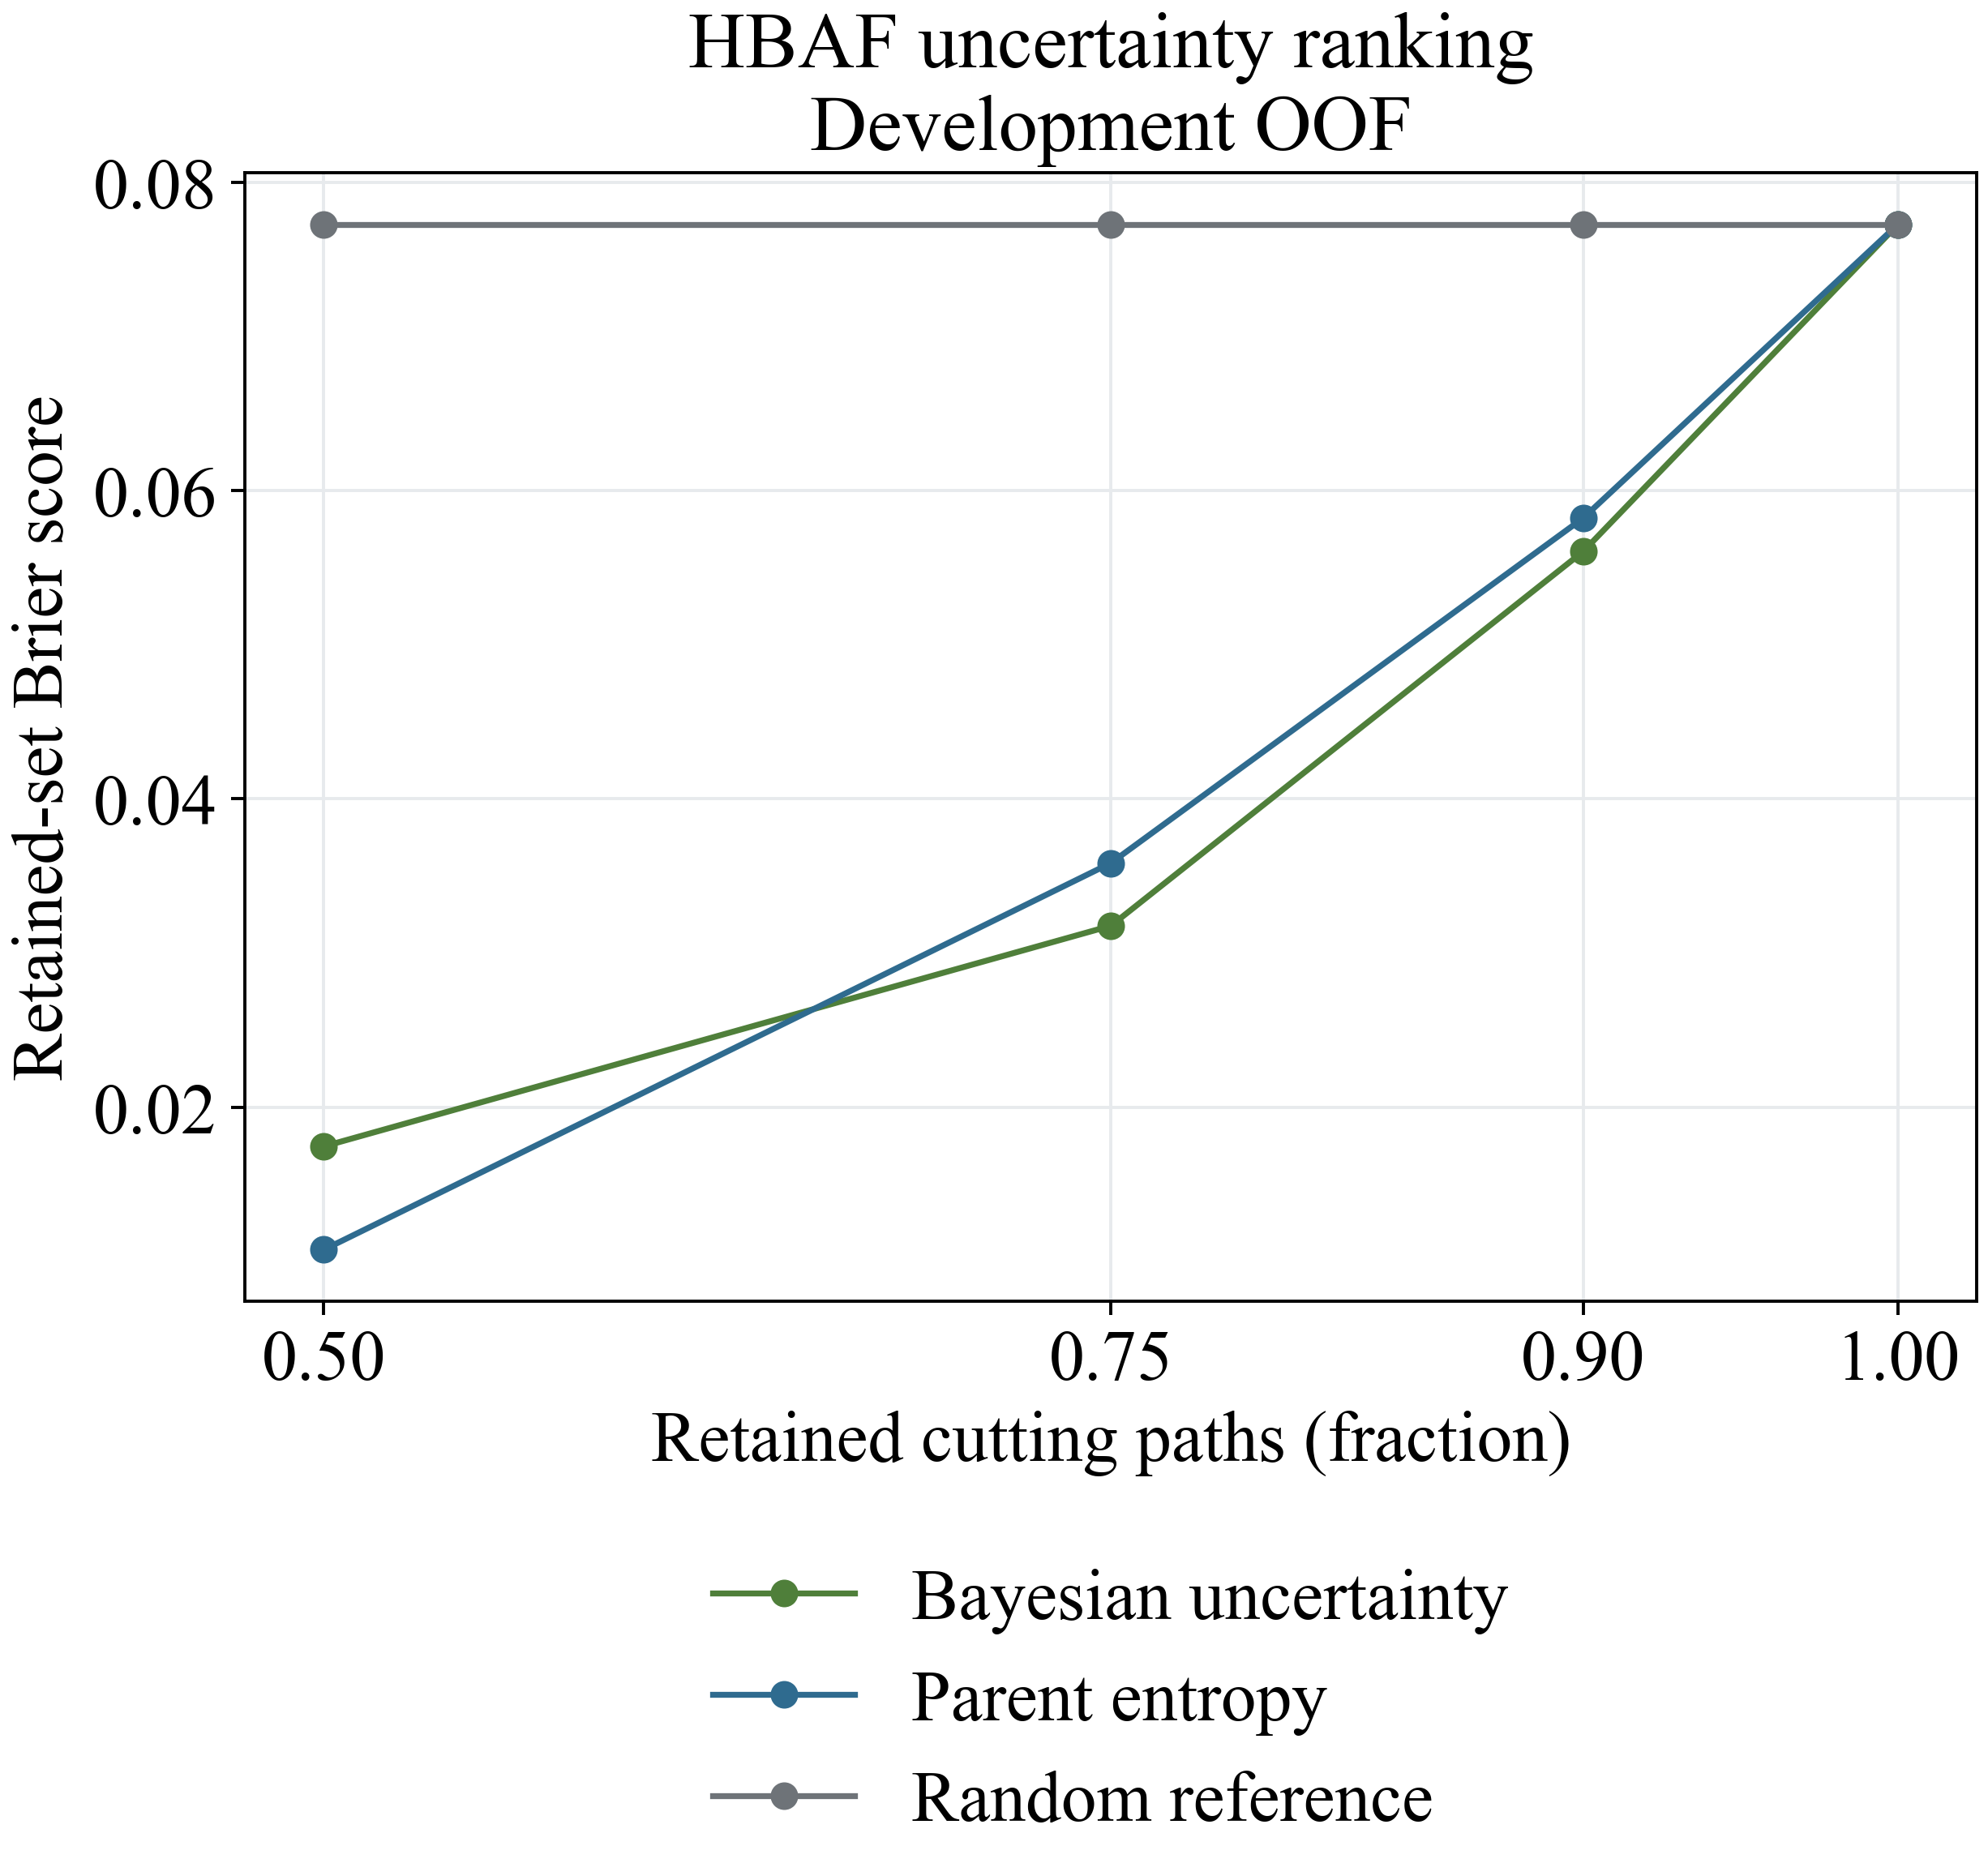

In [27]:
figure, axis = figure_canvas(height_mm=168.0)
curve_styles = [
    (FULL, "Bayesian uncertainty", "#4F7F3A", "Bayesian uncertainty"),
    (FULL, "Parent entropy", "#2F6B8F", "Parent entropy"),
    (FULL, "Random reference", "#6E7378", "Random reference"),
]
for model, policy, color, label in curve_styles:
    rows = risk_coverage[(risk_coverage["Model"].eq(model))
                         & (risk_coverage["Policy"].eq(policy))]
    axis.plot(rows["Coverage"], rows["Brier risk"], marker="o", color=color, label=label)
axis.set_xlabel("Retained cutting paths (fraction)")
axis.set_ylabel("Retained-set Brier score")
axis.set_title("HBAF uncertainty ranking\nDevelopment OOF")
axis.set_xticks(COVERAGES)
axis.grid(color="#E7EAED")
axis.legend(loc="upper center", bbox_to_anchor=(0.5, -0.18),
            frameon=False, ncol=1)
save_show(figure, "05_hbaf_current_risk_coverage.png")


The canvas contrasts the structure of risk degradation. The same HBAF probabilities underlie all three curves, so their differences isolate observation ranking.

## Decision support and asymmetric intervention costs

Decision thresholds represent prespecified cost scenarios, not choices fitted to assessment labels. Net benefit compares intervene-all and intervene-none policies with the frozen probability forecasts.

In [28]:
decision_models = [FULL, PARENT, "GaussianNB calibrated", "Global learned fusion"]
threshold_grid = np.linspace(0.10, 0.90, 17)
decision_rows, cost_rows = [], []
for repeat in range(5):
    prevalence = target_array.mean()
    for threshold in threshold_grid:
        odds = threshold / (1 - threshold)
        for model, value in [("Treat none", 0.0),
                             ("Treat all", prevalence - (1 - prevalence) * odds)]:
            decision_rows.append({"Model": model, "Split": SPLIT,
                                 "Threshold": threshold, "repeat": repeat + 1,
                                 "Net benefit": value})
        for model in decision_models:
            predicted = caches[model]["p"][repeat] >= threshold
            tp = np.sum(predicted & (target_array == 1))
            fp = np.sum(predicted & (target_array == 0))
            decision_rows.append({
                "Model": model, "Split": SPLIT, "Threshold": threshold,
                "repeat": repeat + 1, "Net benefit": (tp - fp * odds) / len(target_array),
            })
    for ratio in (1, 2, 5, 10):
        threshold = 1 / (1 + ratio)
        for model in decision_models:
            predicted = caches[model]["p"][repeat] >= threshold
            fn = np.sum(~predicted & (target_array == 1))
            fp = np.sum(predicted & (target_array == 0))
            cost_rows.append({
                "Model": model, "Split": SPLIT, "FN:FP cost ratio": f"{ratio}:1",
                "Threshold": threshold, "repeat": repeat + 1,
                "False negatives": fn, "False positives": fp,
                "Cost per path": (ratio * fn + fp) / len(target_array),
            })
decision_curve = pd.DataFrame(decision_rows).groupby(
    ["Model", "Split", "Threshold"], sort=False).agg(
    **{"Net benefit": ("Net benefit", "mean")}, Seeds=("repeat", "nunique")
).reset_index()


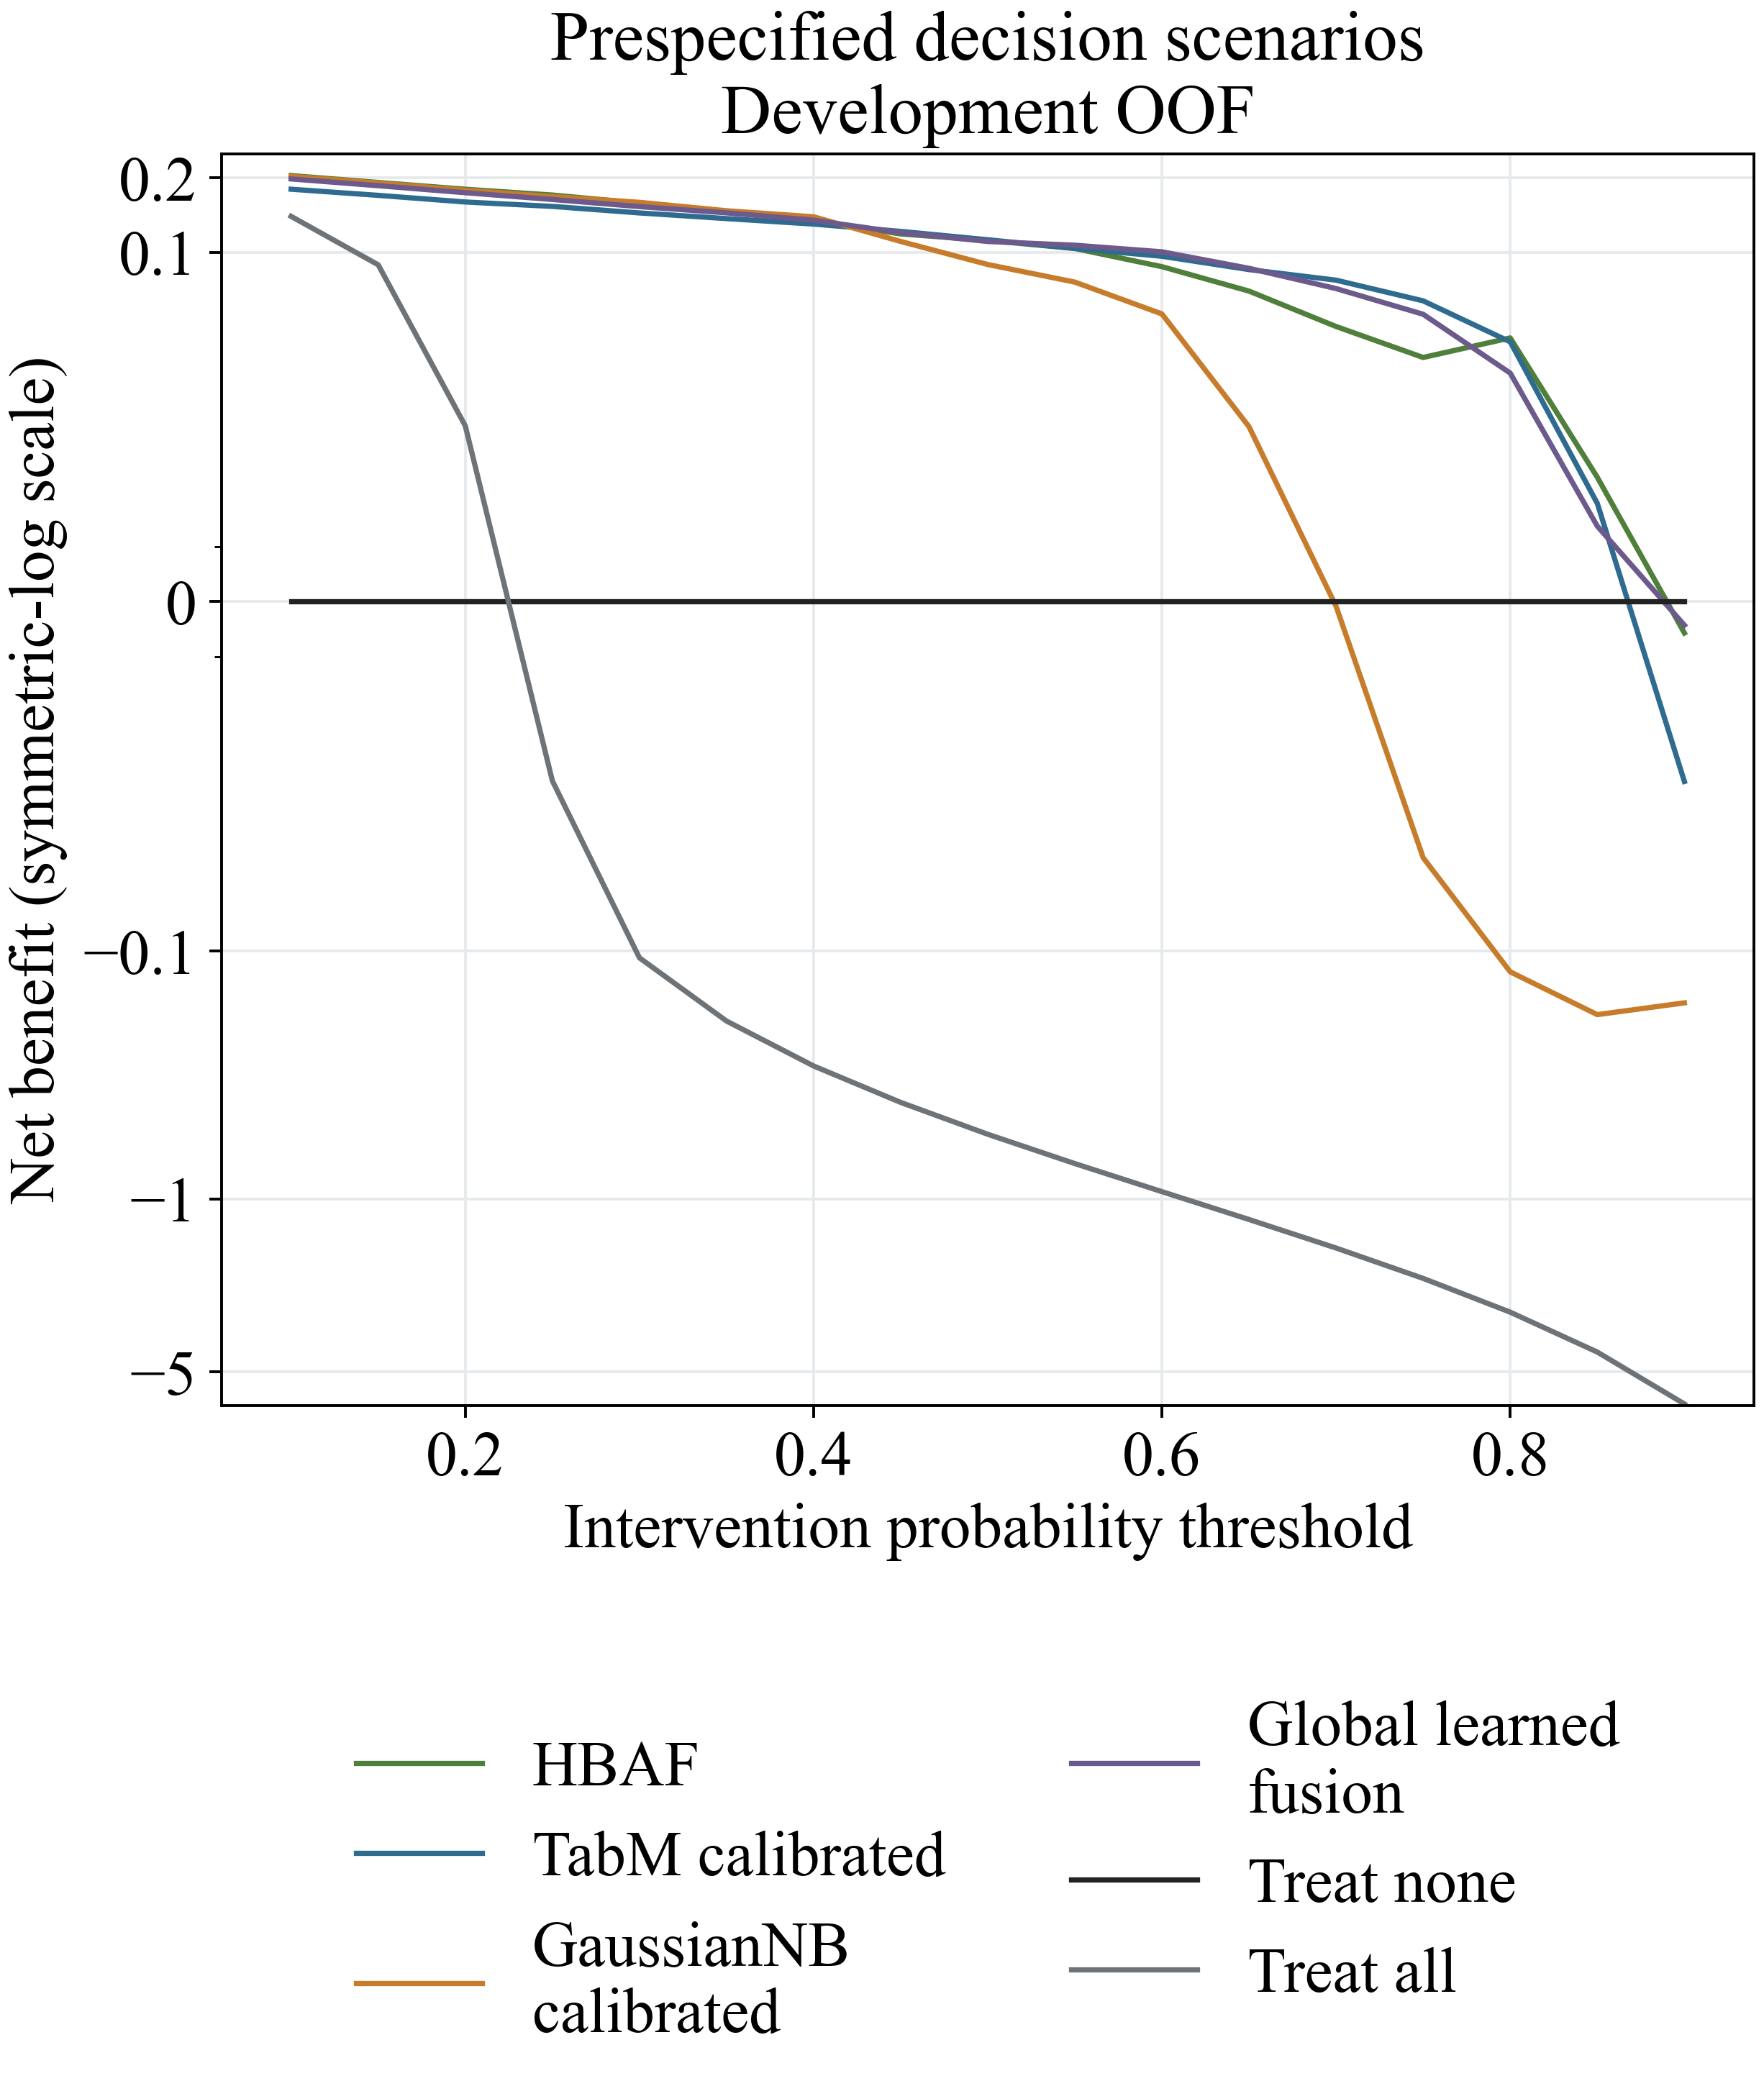

In [33]:
figure, axis = figure_canvas(height_mm=210.0)
curve_colors = ["#4F7F3A", "#2F6B8F", "#C77C2B", "#6D5A8D", "#222222", "#6E7378"]
for model, color in zip(decision_models + ["Treat none", "Treat all"], curve_colors):
    rows = decision_curve[decision_curve["Model"].eq(model)]
    axis.plot(rows["Threshold"], rows["Net benefit"], color=color,
              label=model.replace("Global learned fusion", "Global learned\nfusion").replace("GaussianNB calibrated", "GaussianNB\ncalibrated"))
axis.set_xlabel("Intervention probability threshold")
axis.set_yscale("symlog", linthresh=0.05)
axis.set_ylim(decision_curve["Net benefit"].min()-0.1, 0.25)
axis.set_yticks([-5, -1, -0.1, 0, 0.1, 0.2])
axis.yaxis.set_major_formatter(mpl.ticker.FuncFormatter(
    lambda value, position: f"{value:g}".replace("-", "−")))
axis.set_ylabel("Net benefit (symmetric-log scale)")
axis.set_title("Prespecified decision scenarios\nDevelopment OOF")
axis.grid(color="#E7EAED")
axis.legend(loc="upper center", bbox_to_anchor=(0.5, -0.19),
            frameon=False, ncol=2)
save_show(figure, "05_hbaf_current_decision_curve.png")


Symmetric-log scaling preserves the full negative treat-all reference while resolving model differences around zero; the linear region is −0.05 to 0.05. A favorable region is not a globally optimal deployment threshold. Cost ratios are transparent scenarios; factory downtime, defect and intervention costs were not measured.

In [34]:
cost_keys = ["Model", "Split", "FN:FP cost ratio", "Threshold"]
cost_sensitivity = pd.DataFrame(cost_rows).groupby(cost_keys, sort=False).agg(
    **{"False negatives": ("False negatives", "mean"),
       "False positives": ("False positives", "mean"),
       "Cost per path": ("Cost per path", "mean")},
    Seeds=("repeat", "nunique"),
).reset_index()
display_grouped_tables(cost_sensitivity, cost_keys + ["Seeds"], {
    "Mean errors across fixed repeats": ["False negatives", "False positives"],
    "Scenario-weighted decision cost; lower is better": ["Cost per path"],
})


#### Mean errors across fixed repeats

,Model,Split,FN:FP cost ratio,Threshold,Seeds,False negatives,False positives
0,HBAF,Development OOF,1:1,0.500000,5,30.2000,34.0000
1,TabM calibrated,Development OOF,1:1,0.500000,5,35.0000,28.8000
2,GaussianNB calibrated,Development OOF,1:1,0.500000,5,37.0000,39.8000
3,Global learned fusion,Development OOF,1:1,0.500000,5,35.4000,29.4000
4,HBAF,Development OOF,2:1,0.333333,5,14.0000,55.2000
5,TabM calibrated,Development OOF,2:1,0.333333,5,27.6000,42.6000
6,GaussianNB calibrated,Development OOF,2:1,0.333333,5,15.8000,52.4000
7,Global learned fusion,Development OOF,2:1,0.333333,5,18.0000,51.4000
8,HBAF,Development OOF,5:1,0.166667,5,5.6000,79.8000
9,TabM calibrated,Development OOF,5:1,0.166667,5,20.4000,65.6000


#### Scenario-weighted decision cost; lower is better

,Model,Split,FN:FP cost ratio,Threshold,Seeds,Cost per path
0,HBAF,Development OOF,1:1,0.500000,5,0.1140
1,TabM calibrated,Development OOF,1:1,0.500000,5,0.1133
2,GaussianNB calibrated,Development OOF,1:1,0.500000,5,0.1364
3,Global learned fusion,Development OOF,1:1,0.500000,5,0.1151
4,HBAF,Development OOF,2:1,0.333333,5,0.1478
5,TabM calibrated,Development OOF,2:1,0.333333,5,0.1737
6,GaussianNB calibrated,Development OOF,2:1,0.333333,5,0.1492
7,Global learned fusion,Development OOF,2:1,0.333333,5,0.1552
8,HBAF,Development OOF,5:1,0.166667,5,0.1915
9,TabM calibrated,Development OOF,5:1,0.166667,5,0.2977


## Computation and reproducibility limits

Runtime values describe the measured current pipeline and hardware. Missing measurements remain NA. Inference reuses frozen predictions and does not re-fit the underlying classifiers or inspect locked labels.

In [35]:
runtime_path = TABLES / "hbaf_current_runtime.csv"
runtime_columns = ["model", "repeat", "outer_fold", "fit_seconds",
                   "inference_ms_per_path", "model_size_mb", "parameter_count"]
if runtime_path.is_file():
    runtime = pd.read_csv(runtime_path)
    assert set(runtime_columns).issubset(runtime.columns)
    input_paths.append(runtime_path)
else:
    runtime = pd.DataFrame({"model": CURRENT_MODELS})
    for name in runtime_columns[1:]:
        runtime[name] = np.nan
efficiency = runtime.groupby("model", sort=False).agg(
    **{"Development experiment (s/outer boundary)": ("fit_seconds", "mean"),
       "Gate/control latency (ms/path)": ("inference_ms_per_path", "mean"),
       "Assessment bundle (MB)": ("model_size_mb", "mean"),
       "Gate parameter count": ("parameter_count", "mean")},
).reset_index().rename(columns={"model": "Model"})
efficiency["Split"] = SPLIT
efficiency["Scope"] = "Training includes nested experts and controls; latency and parameters are gate-only"
display_grouped_tables(efficiency, ["Model", "Split", "Scope"], {
    "Measured efficiency": ["Development experiment (s/outer boundary)", "Gate/control latency (ms/path)",
                            "Assessment bundle (MB)", "Gate parameter count"],
})


#### Measured efficiency

,Model,Split,Scope,Development experiment (s/outer boundary),Gate/control latency (ms/path),Assessment bundle (MB),Gate parameter count
0,HBAF,Development OOF,Training includes nested experts and controls; latency and parameters are gate-only,15.6121,0.0785,8.9320,8.9333


Development time includes nested expert fitting and all meta/control experiments. Latency excludes expert inference and measures the gate/control stage; parameter counts are gate-only. Serialized size describes an assessment bundle with notebook-global dependencies, not a portable deployment model. These scopes do not support end-to-end efficiency superiority.

## Bayesian numerical evidence

Posterior regularity is checked independently of predictive scores. A Hessian condition number at least 10⁸ or an unresolved scale-search boundary prevents a positive inferential claim. An exact zero coefficient scale is a legitimate evidence-selected collapse, not a numerical success for an adaptive mechanism.

In [36]:
component_path = TABLES / "hbaf_current_components.csv"
assert component_path.is_file()
components = pd.read_csv(component_path)
component_columns = {
    "repeat", "fold", "hessian_condition", "scale_at_boundary",
    "coefficient_collapsed", "hierarchy_collapsed", "mode_objective_spread",
}
assert component_columns.issubset(components.columns)
assert not components.duplicated(["repeat", "fold"]).any()
assert len(components) == 15 and components["repeat"].nunique() == 5
assert components[list(component_columns)].notna().all().all()
for name in ["scale_at_boundary", "coefficient_collapsed", "hierarchy_collapsed"]:
    assert components[name].isin([True, False]).all()
condition = components["hessian_condition"].to_numpy(float)
numerical_valid = bool(np.isfinite(condition).all() and (condition < 1e8).all()
                       and not components["scale_at_boundary"].any())
adaptive_activity = bool((~components["coefficient_collapsed"]).any())
input_paths.append(component_path)
component_summary = components[["repeat", "fold", "hessian_condition",
    "scale_at_boundary", "coefficient_collapsed", "hierarchy_collapsed",
    "mode_objective_spread"]].copy()
display_grouped_tables(component_summary, ["repeat", "fold"], {
    "Posterior regularity and evidence boundaries": [
        "hessian_condition", "scale_at_boundary", "mode_objective_spread"],
    "Supported adaptive complexity": ["coefficient_collapsed", "hierarchy_collapsed"],
})


#### Posterior regularity and evidence boundaries

,repeat,fold,hessian_condition,scale_at_boundary,mode_objective_spread
0,1,1,1950.6564,False,0.4899
1,1,2,552.2986,False,0.0000
2,1,3,18.9488,False,0.0000
3,2,1,51.1792,False,0.0000
4,2,2,9.5140,False,0.0000
5,2,3,1125.3652,False,0.0000
6,3,1,1525.5712,False,0.0000
7,3,2,128.9878,False,0.0000
8,3,3,7553.6544,False,0.0000
9,4,1,1.4018,False,0.0000


#### Supported adaptive complexity

,repeat,fold,coefficient_collapsed,hierarchy_collapsed
0,1,1,False,False
1,1,2,False,False
2,1,3,False,True
3,2,1,True,False
4,2,2,False,False
5,2,3,False,True
6,3,1,False,True
7,3,2,False,False
8,3,3,False,False
9,4,1,True,False


A collapsed coefficient model is retained as a negative adaptive result. Objective spread across posterior starts is reported as an approximation limitation; no threshold is retrospectively chosen to improve admission.

In [39]:
output_frames = {
    "hbaf_current_summary.csv": summary,
    "hbaf_current_repeat_metrics.csv": repeat_metrics,
    "hbaf_current_experiment_metrics.csv": experiment_results,
    "hbaf_current_statistics.csv": statistics,
    "hbaf_current_risk_coverage.csv": risk_coverage,
    "hbaf_current_selective_statistics.csv": selective_statistics,
    "hbaf_current_mcnemar.csv": mcnemar,
    "hbaf_current_decision_curve.csv": decision_curve,
    "hbaf_current_cost_sensitivity.csv": cost_sensitivity,
    "hbaf_current_efficiency.csv": efficiency,
}
for name, frame in output_frames.items():
    frame.to_csv(TABLES / name, index=False)


## Interpretation and limitations

The matched comparisons do not establish a consistent Bayesian advantage over the parent and simpler controls. Conditional Laplace uncertainty remains numerically unvalidated.

These experiments evaluate terminal prediction and uncertainty ranking. They do not measure causal early monitoring, production intervention costs, end-to-end deployment latency or independent cross-machine confirmation.
